In [ ]:
Project 3: Linear Regression Model Development and Evaluation

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["HouseValue"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [35]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HouseValue,0


In [36]:
X = df.drop("HouseValue", axis=1)

y = df["HouseValue"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [40]:
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))

RMSE: 0.7122822941928031
MAE: 0.5252102477114801
R2: 0.622056267099518


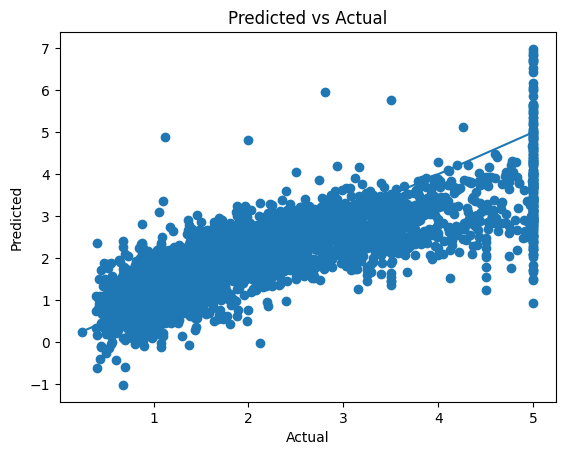

In [41]:
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Predicted vs Actual")

plt.show()

In [ ]:
Project 4: Logistic Regression Model Implementation and Evaluation for Binary Classification

In [68]:
import pandas as pd

In [45]:
url = "https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv"

df = pd.read_csv(url)

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [46]:
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [48]:
df = df[["pclass","sex","age","sibsp","parch","fare","embarked","survived"]]

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7824427480916031
Precision: 0.7816091954022989
Recall: 0.6415094339622641
F1 Score: 0.7046632124352331


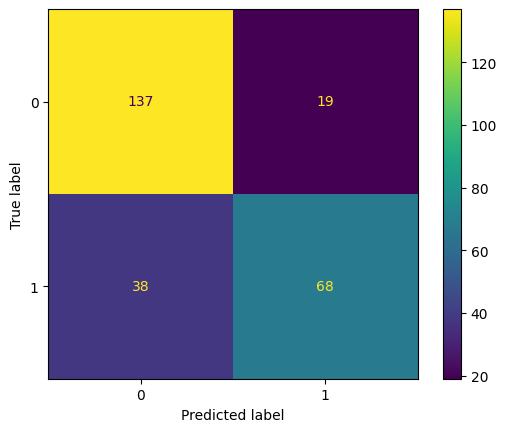

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

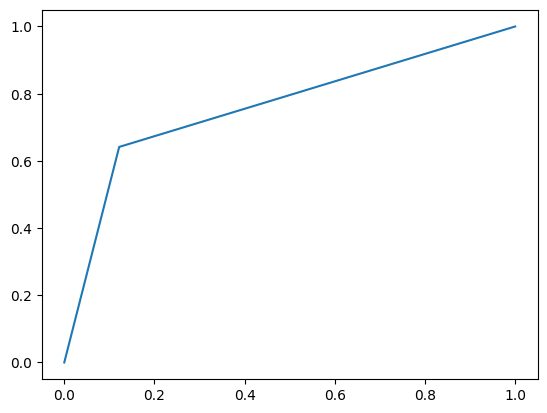

AUC: 0.7598572810836961


In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)

plt.show()

print("AUC:", roc_auc_score(y_test, y_pred))

In [ ]:
Project 5: Hyperparameter Optimization for Titanic Survival Classifier

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [57]:
X = df.drop("survived", axis=1)

y = df["survived"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [59]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [61]:
y_pred = model.predict(X_test)

print("Default Accuracy:", accuracy_score(y_test, y_pred))

Default Accuracy: 0.8053435114503816


In [60]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {"C":[0.1,1,10]}
)

grid.fit(X_train, y_train)

GridSearchCV(estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.1, 1, 10]})

In [62]:
y_pred = grid.predict(X_test)

print("Grid Accuracy:", accuracy_score(y_test, y_pred))

Grid Accuracy: 0.7900763358778626


In [65]:
random = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    {"C":[0.1,1,10]},
    n_iter=3
)

random.fit(X_train, y_train)

RandomizedSearchCV(estimator=LogisticRegression(max_iter=1000), n_iter=3,
                   param_distributions={'C': [0.1, 1, 10]})

In [66]:
y_pred = random.predict(X_test)

print("Random Accuracy:", accuracy_score(y_test, y_pred))

Random Accuracy: 0.7900763358778626


In [67]:
print("Grid Best:", grid.best_params_)

print("Random Best:", random.best_params_)

Grid Best: {'C': 0.1}
Random Best: {'C': 0.1}


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.7634408602150538
Recall: 0.6826923076923077
F1 Score: 0.7208121827411168
